# Fase 1 — Recolección de datos y separación train/test

**TP1 — Regresión e Introducción a la Evaluación de Modelos**
Materia 72.75 — Aprendizaje Automático — ITBA

Cubre la consigna **2.1 (Separación de datos)** del enunciado.

---

## Ubicación en el pipeline

Seguimos el *Pipeline clásico de un proyecto de ML* de la Clase 3 (slides 16 y 101):

| Paso | Etapa | Estado |
|---|---|---|
| 1 | Definición del problema | ✅ |
| 2 | **Recolección de datos** | ✅ **este notebook** |
| 3 | **Data Splitting (train / validation / test)** | ✅ **este notebook** |
| 4 | Limpieza de datos (faltantes, outliers, inconsistencias) | Fase 2 |
| 5 | EDA (distribuciones, correlaciones) | Fase 2 |
| 6 | Feature engineering / selection | Fases 3 y 5 |
| 7 | Modelado | Fase 4 |
| 8 | Regularización | Fase 5 |
| 9 | Evaluación en Dev | Fases 4 y 5 |
| 11 | Selección del modelo y evaluación final en Test | Fase 6 |

## Qué se hace en esta fase, y qué explícitamente *no* se hace

| Sí | No |
|---|---|
| Leer el CSV desde la ruta local | Imputar valores |
| Verificar la integridad **estructural** del archivo | Eliminar outliers |
| Separar train y test | Escalar o codificar |
| Auditar que la separación sea limpia | Calcular medias, medianas o IQR |

La columna derecha no es un olvido: es el punto metodológico central del TP.
Todo lo que dependa de un **estadístico** de los datos se ajusta en las fases
siguientes y **usando sólo el train**.

In [2]:
# El notebook trabaja desde la raíz del repo para poder importar src/.
# (En VS Code esto ya lo garantiza .vscode/settings.json, pero dejarlo explícito
#  hace que el notebook funcione también al ejecutarlo desde la terminal.)
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import RANDOM_SEED, TARGET, TEST_SIZE, FIGURES_DIR
from src.data import (
    cargar_datos_crudos,
    separar_train_test,
    verificar_split,
    guardar_splits,
    cargar_splits,
)

pd.set_option("display.width", 110)
print(f"Semilla del proyecto: {RANDOM_SEED} | Target: {TARGET}")

Semilla del proyecto: 42 | Target: charges


---

## 1. Recolección de datos *(paso 2 del pipeline)*

El dataset se lee **siempre** desde `data/raw/insurance.csv`. El pipeline nunca
descarga nada en tiempo de ejecución.

> **Por qué no usar `kagglehub`:** `dataset_download()` trae la *latest version*
> publicada. Si esa versión cambiara entre hoy y la defensa, los números de la
> presentación dejarían de reproducirse, y además el análisis dependería de tener
> internet. El CSV está versionado en el repositorio justamente para congelar los
> datos sobre los que se obtuvieron los resultados.

In [3]:
df = cargar_datos_crudos()

print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dimensiones: 1338 filas x 7 columnas


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### 1.1 Verificación estructural

Esto **no es limpieza de datos**: no se modifica ni se descarta nada. Es un control
de que el archivo es el que esperamos (columnas correctas, tipos coherentes, cantidad
de filas conocida). `cargar_datos_crudos()` falla con un error explícito si el CSV
fuera reemplazado por otra versión, para que el problema aparezca acá y no cinco
fases después disfrazado de un resultado raro.

El diagnóstico completo de faltantes, duplicados y outliers —y las **decisiones**
sobre qué hacer con ellos— corresponde al paso 4 del pipeline (Fase 2), y se hará
mirando sólo el train.

In [4]:
print("--- Tipos de dato ---")
print(df.dtypes.to_string())

print("\n--- Valores faltantes por columna ---")
print(df.isna().sum().to_string())

print(f"\n--- Filas exactamente duplicadas: {df.duplicated().sum()} ---")
display(df[df.duplicated(keep=False)])

--- Tipos de dato ---
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64

--- Valores faltantes por columna ---
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0

--- Filas exactamente duplicadas: 1 ---


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


**Observaciones estructurales:**

- **No hay valores faltantes** en ninguna columna. El análisis formal de la consigna
  1.2 se documenta igual en la Fase 2, sobre el train.
- **Hay un par de filas exactamente idénticas** (índices 195 y 581). Se deja constancia
  ahora porque tiene una implicancia sobre el split: si una copia cayera en train y la
  otra en test, el modelo sería evaluado sobre un dato que ya vio durante el
  entrenamiento. Más abajo se audita explícitamente qué ocurrió con ellas.
- Los tipos son los esperados. Nota: en pandas 3.0 las columnas de texto tienen dtype
  `str` (no `object` como en pandas 2.x).

---

## 2. Data Splitting *(paso 3 del pipeline)*

### 2.1 Por qué el split va acá y no después de limpiar

El enunciado numera *"1. Limpieza de datos"* antes de *"2.1 Separación de datos"*,
pero ese es el orden de **exposición** de las consignas, no el de **ejecución**.

El pipeline de la Clase 3 (slide 16) coloca **Data Splitting como paso 3**, antes de
*Limpieza de datos* (paso 4) y antes del *EDA* (paso 5). Y la Clase 2 (slides 93–96)
plantea explícitamente la pregunta *"¿Dónde realizarían la separación train-test?"*
con la advertencia:

> *"Cuidado con el data leakage. Si quitamos outliers e imputamos valores usando TODO
> el dataset, información que luego irá al test estará siendo usada para train."*

El mecanismo concreto: si imputáramos con la mediana del dataset completo, esa mediana
contiene información de las filas que van a ir al test. El modelo entrenaría con un
valor que resume, en parte, datos que se supone que nunca vio. El error de test dejaría
de ser una estimación honesta de cómo funciona el modelo con datos nuevos, y saldría
**optimistamente sesgado**.

Lo mismo vale para el IQR usado para detectar outliers, para la media y el desvío del
escalado, y para el target encoding de las categóricas.

La Clase 3 (slide 30) lo dice de forma directa:

> *"Antes de seguir, crear el conjunto de test y separar esos datos para no volverlos
> a usar hasta el final del proyecto."*

### 2.2 Método de separación

Se usa **muestreo aleatorio simple**, tal como indica la Clase 3 (slide 30):

> *"Típicamente seleccionar **aleatoriamente** 20% de los datos (a no ser que tengamos
> un dataset muy grande)."*

La semilla (`RANDOM_SEED = 42`, definida en `src/config.py`) se fija para que el sorteo
sea siempre el mismo. Sin fijarla, cada ejecución produciría una partición distinta y
por lo tanto un RMSE distinto, y los números del informe no coincidirían con los que se
obtienen al correr el código. La semilla se fijó una sola vez y no se modificó después:
probar varias semillas y quedarse con la que da mejor resultado equivaldría a elegir la
partición más favorable en lugar del mejor modelo.

### 2.3 ¿Qué proporción train/test?

La Clase 2 (slide 83) propone **60-20-20** como regla para datasets de tamaño
pequeño-mediano. Ese esquema reserva un *dev set* fijo para elegir modelo.

Acá se usa **80-20**, y el 20% de dev "desaparece" porque **la validación se hace con
k-fold sobre el train** (consigna 2.2), no con un holdout fijo. Es la recomendación de
la Clase 2 (slide 85) y de la Clase 3 (slide 15): para datasets pequeños, la validación
cruzada *"nos permite utilizar los datos de manera más eficiente"*, porque cada
observación se usa una vez para validar y el resto de las veces para entrenar.

El 20% de test coincide además con lo que indica la Clase 3 (slide 30).

El criterio de la Clase 2 (slide 69) para el test es: no hace falta que sea tan grande
como el train, pero debe tener suficientes datos para representar la muestra.

In [5]:
n = len(df)

filas = []
for t in (0.15, 0.20, 0.25, 0.30):
    n_te = int(round(n * t))
    filas.append({"test_size": f"{t:.0%}", "n_train": n - n_te, "n_test": n_te})

pd.DataFrame(filas)

,test_size,n_train,n_test
0,15%,1137,201
1,20%,1070,268
2,25%,1004,334
3,30%,937,401


**Decisión: `test_size = 0.20`.**

- Con 15% el test queda en 201 filas, pocas para estimar el error de forma estable.
- Con 30% el test tendría 401 filas, pero le saca 133 filas al train sin ganar nada
  relevante en precisión de la estimación.
- **20% deja 1070 filas de train y 268 de test**, que es un equilibrio razonable entre
  tener con qué entrenar y tener con qué estimar el error. Es además el valor que
  sugiere la Clase 3.

---

## 3. Split definitivo

In [6]:
train, test = separar_train_test(df)

print(f"Train: {train.shape[0]:5d} filas ({train.shape[0]/len(df):.1%})")
print(f"Test : {test.shape[0]:5d} filas ({test.shape[0]/len(df):.1%})")

Train:  1070 filas (80.0%)
Test :   268 filas (20.0%)


### 3.1 Auditoría del split

Tres controles automáticos. Los dos primeros son de integridad; el tercero es el que
protege contra el leakage del par de filas duplicadas detectado en la sección 1.1.

In [7]:
chequeos = verificar_split(train, test)

for k, v in chequeos.items():
    print(f"{k:32s}: {v:,.4f}" if isinstance(v, float) else f"{k:32s}: {v}")

n_train                         : 1070
n_test                          : 268
prop_test                       : 0.2003
solapamiento_indices            : 0
filas_identicas_compartidas     : 1
media_target_train              : 13,346.0897
media_target_test               : 12,968.3171


- `solapamiento_indices = 0` → ninguna fila quedó en ambos conjuntos. La partición es
  correcta: no se perdió ni se repitió ningún registro.
- `filas_identicas_compartidas = 1` → **el par de filas duplicadas quedó repartido**: la
  195 cayó en train y la 581 en test. Es decir, hay una fila del test que es idéntica a
  una fila que el modelo verá durante el entrenamiento.

**¿Qué se hace con eso?** Se documenta y se deja como está, por tres razones:

1. **Es el orden del pipeline.** El tratamiento de duplicados pertenece al paso 4
   (*Limpieza de datos*, Clase 2 slide 26), que va **después** del split. Eliminar filas
   antes de separar sería adelantar una etapa.
2. **La magnitud es despreciable:** 1 fila sobre 268 es el **0.37%** del test.
3. **El tipo de modelo importa.** Este riesgo es serio en modelos con capacidad de
   memorizar observaciones individuales (árboles, KNN, redes). Una regresión lineal o
   polinómica no memoriza puntos: ajusta coeficientes globales, y una fila repetida sólo
   pesa marginalmente más en la suma de cuadrados. El efecto sobre el RMSE de test es
   inapreciable.

Queda registrado como una limitación conocida y cuantificada del experimento. En la Fase 2
se verificará cuántos duplicados quedan **dentro del train**, que es donde corresponde
tratarlos.

### 3.2 ¿El test representa la muestra?

La Clase 2 (slide 69) pide que el conjunto de test *"represente los datos reales en los
que el modelo se usará"* y que *"tenga suficientes datos para representar la muestra"*.

El muestreo aleatorio cumple ese requisito por construcción **en promedio**, pero
conviene verificar que en esta partición concreta no haya quedado ningún desbalance
llamativo. Es un control de sanidad, no una decisión de modelado.

In [8]:
num_cols = ["age", "bmi", "children", TARGET]

comparacion = pd.DataFrame({
    "train_media": train[num_cols].mean(),
    "test_media": test[num_cols].mean(),
    "train_desvio": train[num_cols].std(),
    "test_desvio": test[num_cols].std(),
})
comparacion["dif_medias_%"] = (
    100 * (comparacion["test_media"] - comparacion["train_media"]) / comparacion["train_media"]
)
comparacion.round(2)

,train_media,test_media,train_desvio,test_desvio,dif_medias_%
age,39.36,38.61,14.07,13.96,-1.90
bmi,30.56,31.07,6.04,6.31,1.68
children,1.11,1.04,1.22,1.16,-5.66
charges,13346.09,12968.32,12019.51,12483.20,-2.83


In [9]:
cat_cols = ["sex", "smoker", "region"]

for col in cat_cols:
    prop = pd.DataFrame({
        "train_%": 100 * train[col].value_counts(normalize=True),
        "test_%": 100 * test[col].value_counts(normalize=True),
    })
    prop["dif_pp"] = prop["test_%"] - prop["train_%"]
    print(f"--- {col} ---")
    print(prop.round(2).to_string())
    print()

--- sex ---
        train_%  test_%  dif_pp
sex                            
female    48.79   52.24    3.45
male      51.21   47.76   -3.45

--- smoker ---
        train_%  test_%  dif_pp
smoker                         
no        79.44   79.85    0.41
yes       20.56   20.15   -0.41

--- region ---
           train_%  test_%  dif_pp
region                            
northeast    24.95   21.27   -3.68
northwest    23.93   25.75    1.82
southeast    26.45   30.22    3.78
southwest    24.67   22.76   -1.91



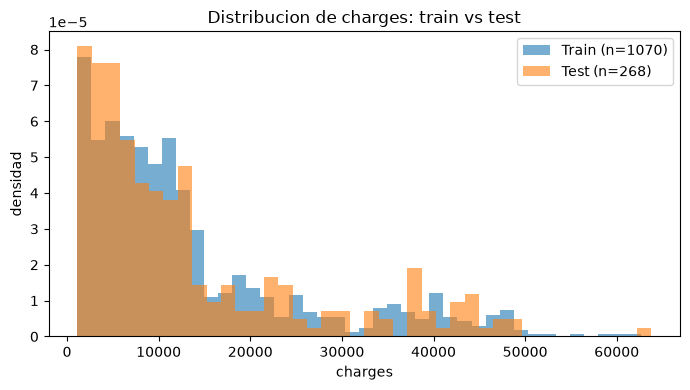

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(train[TARGET], bins=40, density=True, alpha=0.6, label=f"Train (n={len(train)})")
ax.hist(test[TARGET], bins=40, density=True, alpha=0.6, label=f"Test (n={len(test)})")
ax.set_title("Distribucion de charges: train vs test")
ax.set_xlabel("charges")
ax.set_ylabel("densidad")
ax.legend()

plt.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / "01_distribucion_charges_train_test.png", dpi=150, bbox_inches="tight")
plt.show()

Las medias y desvíos de las variables numéricas difieren en pocos puntos porcentuales,
las proporciones de las categóricas son similares entre ambos conjuntos, y las
distribuciones de `charges` se superponen. El test resulta representativo de la muestra,
que es lo que pide la Clase 2.

El histograma muestra además que `charges` tiene una forma marcadamente asimétrica, con
una cola larga hacia la derecha. Eso se analiza en la Fase 2 (EDA), donde corresponde
según el pipeline.

---

## 4. Persistencia de los splits

Se guardan en `data/processed/`, conservando el índice original del CSV para poder
rastrear cada fila hasta su origen.

A partir de la Fase 2, **ningún notebook vuelve a abrir el CSV crudo**: todos entran por
`cargar_splits()`. Así es estructuralmente imposible recalcular por error un estadístico
sobre el dataset completo.

In [11]:
guardar_splits(train, test)

train_recargado, test_recargado = cargar_splits()
print(f"train.csv -> {train_recargado.shape}")
print(f"test.csv  -> {test_recargado.shape}")
print(f"Indices preservados: {(train_recargado.index == train.index).all()}")

train.csv -> (1070, 7)
test.csv  -> (268, 7)
Indices preservados: True


> Los archivos de `data/processed/` están en el `.gitignore`: no se versionan porque se
> regeneran de forma determinista con `python -m src.data`. Lo que garantiza la
> reproducibilidad es la semilla fijada en `src/config.py` más el CSV crudo versionado,
> no los archivos derivados.

---

## Conclusiones de la Fase 1

| Decisión | Valor | Justificación |
|---|---|---|
| Momento del split | Inmediatamente tras la carga | Paso 3 del pipeline (Clase 3, slide 16); evitar data leakage (Clase 2, slides 93–96) |
| Método | Muestreo aleatorio simple | Clase 3, slide 30 |
| Proporción | 80% train / 20% test → 1070 / 268 filas | Clase 3 slide 30; el dev fijo se reemplaza por k-fold sobre train (Clase 2 slide 85) |
| Semilla | 42, fijada en `src/config.py` | Reproducibilidad de los resultados |
| Duplicados | Detectados y documentados, no tratados aún | Corresponden al paso 4 del pipeline (Fase 2). El par quedó repartido entre train y test: 1 fila = 0.37% del test |

**Estado del test set:** separado y guardado. No se vuelve a mirar hasta la Fase 6.

**Siguiente:** Fase 2 — Limpieza de datos y EDA sobre el train (pasos 4 y 5 del pipeline,
consignas 1.2 y 1.3).